# Detección de Huecos en Carreteras (Pothole Detection)
### Transfer Learning con InceptionV3 — Dataset: `taroii/pothole-detection`

**Fases:**
1. Pre-procesamiento y análisis de datos (EDA)
2. Red neuronal convolucional con Transfer Learning
3. Entrenamiento y optimización del modelo

## 0. Setup y Dependencias

In [2]:
%load_ext autoreload
%autoreload 2

import os, sys, random, warnings
warnings.filterwarnings('ignore')

# Asegurar que la raíz del repo esté en el path
project_root = os.path.abspath('.')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from collections import Counter

from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from datasets import load_dataset

# Módulos del repo
from src.model_training import train_model, evaluate
from src.utils import unnormalize
from src.xai import (
    attach_hooks, run_forward, run_backward,
    compute_gradcam, resize_cam, tensor_to_uint8
)

# ── Reproducibilidad ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark    = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')
print(f'Device   : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU      : {torch.cuda.get_device_name(0)}')

Failed to read module file 'c:\Users\juanc\OneDrive\Inicio\Desktop\Deep learning\proyecto_deep\src\model_training.py' for module 'src.model_training': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\Users\juanc\AppData\Roaming\Python\Python313\site-packages\IPython\extensions\deduperreload\deduperreload.py", line 219, in update_sources
    self.source_by_modname[new_modname] = f.read()
                                          ~~~~~~^^
  File "c:\Users\juanc\AppData\Local\Programs\Python\Python313\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x90 in position 5124: character maps to <undefined>


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
PyTorch  : 2.11.0+cpu
CUDA     : False
Device   : cpu


---
## 1. Pre-procesamiento y Análisis de Datos (EDA)

### 1.1 Carga del Dataset

In [3]:
print('Descargando dataset taroii/pothole-detection ...')
ds = load_dataset('taroii/pothole-detection')
print('\nEstructura del dataset:')
print(ds)

Descargando dataset taroii/pothole-detection ...



Estructura del dataset:
DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 200
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 165
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 72
    })
})


In [4]:
# Inspeccionar features y primer ejemplo
split_name = list(ds.keys())[0]   # primer split disponible
sample = ds[split_name][0]

print(f'Splits disponibles : {list(ds.keys())}')
print(f'Features           : {list(sample.keys())}')

# Detectar automáticamente la columna de imagen y de etiqueta
img_key   = next(k for k in sample if isinstance(sample[k], Image.Image))
label_key = next(k for k in sample if k != img_key)

print(f'Columna imagen     : "{img_key}"')
print(f'Columna etiqueta   : "{label_key}"')
print(f'Tipo etiqueta      : {type(sample[label_key])}')
print(f'Valor etiqueta     : {sample[label_key]}')

Splits disponibles : ['train', 'validation', 'test']
Features           : ['image', 'label']
Columna imagen     : "image"
Columna etiqueta   : "label"
Tipo etiqueta      : <class 'int'>
Valor etiqueta     : 0


In [5]:
# Construir lista de nombres de clase
raw_split = ds[split_name]

if hasattr(raw_split.features[label_key], 'names'):
    CLASS_NAMES = raw_split.features[label_key].names
else:
    # Si las etiquetas son strings, usarlas directamente
    unique_labels = sorted(set(raw_split[label_key]))
    if isinstance(unique_labels[0], str):
        CLASS_NAMES = unique_labels
    else:
        CLASS_NAMES = [str(i) for i in unique_labels]

NUM_CLASSES = len(CLASS_NAMES)
print(f'Clases ({NUM_CLASSES}): {CLASS_NAMES}')

Clases (2): ['no pothole', 'pothole']


### 1.2 Análisis Exploratorio (EDA)

In [6]:
# ── Distribución de clases por split ──────────────────────────────────────────
print('=== Distribución de clases por split ===')
for split in ds.keys():
    labels = ds[split][label_key]
    if isinstance(labels[0], str):
        counts = Counter(labels)
    else:
        counts = Counter(
            CLASS_NAMES[l] if l < len(CLASS_NAMES) else str(l)
            for l in labels
        )
    total = sum(counts.values())
    print(f'\nSplit "{split}" — {total} imágenes')
    for cls, cnt in sorted(counts.items()):
        print(f'  {cls:20s}: {cnt:4d}  ({100*cnt/total:.1f}%)')

=== Distribución de clases por split ===

Split "train" — 200 imágenes
  no pothole          :  100  (50.0%)
  pothole             :  100  (50.0%)

Split "validation" — 165 imágenes
  no pothole          :   65  (39.4%)
  pothole             :  100  (60.6%)

Split "test" — 72 imágenes
  no pothole          :   26  (36.1%)
  pothole             :   46  (63.9%)


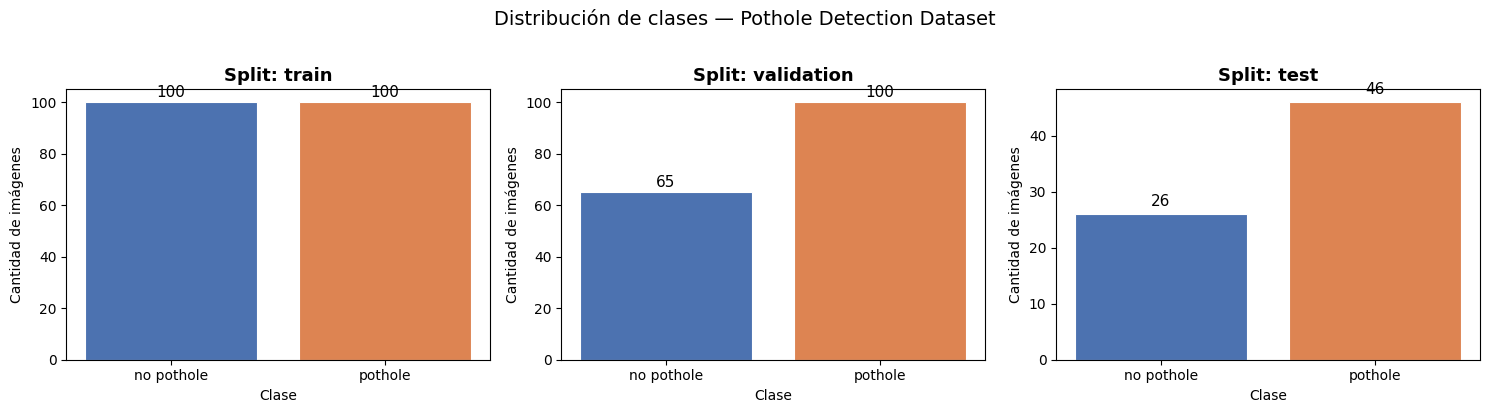

In [7]:
# ── Gráfico de distribución ───────────────────────────────────────────────────
colors = ['#4C72B0', '#DD8452']
fig, axes = plt.subplots(1, len(ds.keys()), figsize=(5 * len(ds.keys()), 4))
if len(ds.keys()) == 1:
    axes = [axes]

for ax, split in zip(axes, ds.keys()):
    labels = ds[split][label_key]
    if isinstance(labels[0], str):
        counts = Counter(labels)
    else:
        counts = Counter(
            CLASS_NAMES[l] if l < len(CLASS_NAMES) else str(l)
            for l in labels
        )
    classes = list(counts.keys())
    vals    = list(counts.values())
    bars = ax.bar(classes, vals, color=colors[:len(classes)], edgecolor='white', linewidth=0.8)
    ax.set_title(f'Split: {split}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Cantidad de imágenes')
    ax.set_xlabel('Clase')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(val), ha='center', va='bottom', fontsize=11)

plt.suptitle('Distribución de clases — Pothole Detection Dataset', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('output/class_distribution.png', bbox_inches='tight', dpi=120)
plt.show()

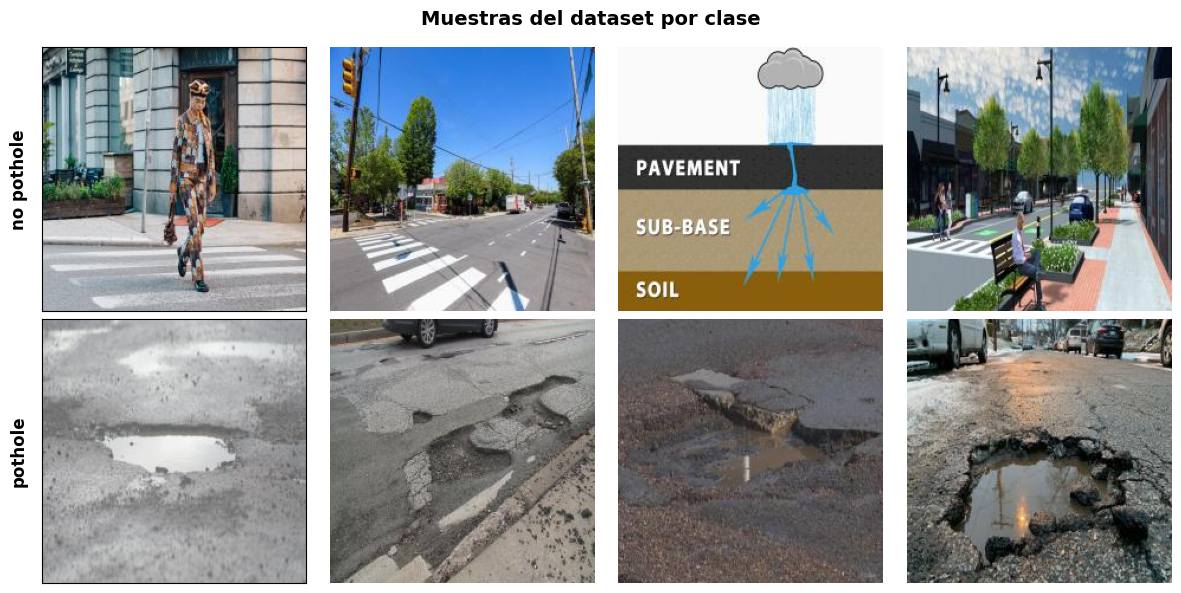

In [8]:
# ── Muestras visuales por clase ───────────────────────────────────────────────
SAMPLES_PER_CLASS = 4
split_data = ds[split_name]

# Agrupar índices por clase
indices_by_class = {cls: [] for cls in CLASS_NAMES}
for idx, lbl in enumerate(split_data[label_key]):
    cls_name = CLASS_NAMES[lbl] if isinstance(lbl, int) else lbl
    indices_by_class[cls_name].append(idx)

fig, axes = plt.subplots(NUM_CLASSES, SAMPLES_PER_CLASS,
                          figsize=(3 * SAMPLES_PER_CLASS, 3 * NUM_CLASSES))
if NUM_CLASSES == 1:
    axes = [axes]

for row, cls in enumerate(CLASS_NAMES):
    sampled_idxs = random.sample(indices_by_class[cls], min(SAMPLES_PER_CLASS, len(indices_by_class[cls])))
    for col, idx in enumerate(sampled_idxs):
        img = split_data[idx][img_key]
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(cls, fontsize=12, fontweight='bold', rotation=90, labelpad=10)
            axes[row][col].yaxis.set_label_position('left')
            axes[row][col].axis('on')
            axes[row][col].set_xticks([])
            axes[row][col].set_yticks([])

plt.suptitle('Muestras del dataset por clase', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output/sample_images.png', bbox_inches='tight', dpi=120)
plt.show()

Analizando dimensiones de imágenes (muestra de 100)...

Altura  — min:  224 | max:  224 | mean: 224
Anchura — min:  224  | max:  224  | mean: 224
Canales — únicos: {3}


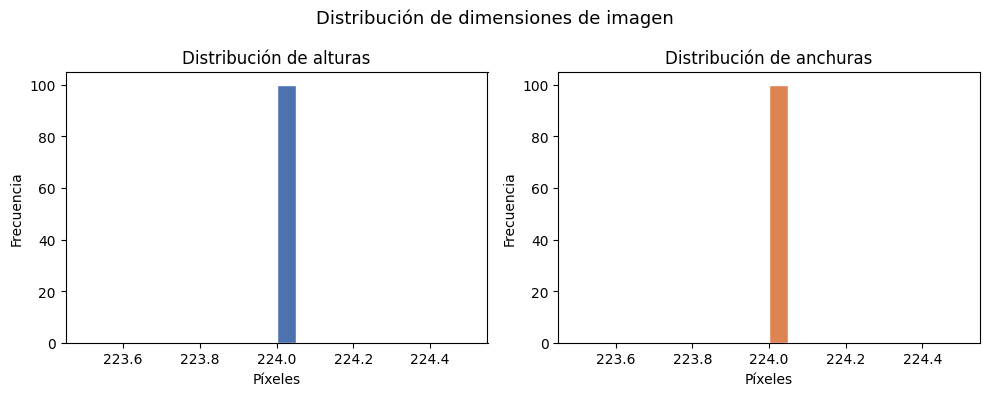

In [9]:
# ── Estadísticas de dimensiones de imagen ─────────────────────────────────────
print('Analizando dimensiones de imágenes (muestra de 100)...')
sample_idxs = random.sample(range(len(split_data)), min(100, len(split_data)))

widths, heights, channels = [], [], []
for idx in sample_idxs:
    img = split_data[idx][img_key]
    arr = np.array(img)
    heights.append(arr.shape[0])
    widths.append(arr.shape[1])
    channels.append(arr.shape[2] if arr.ndim == 3 else 1)

print(f'\nAltura  — min: {min(heights):4d} | max: {max(heights):4d} | mean: {np.mean(heights):.0f}')
print(f'Anchura — min: {min(widths):4d}  | max: {max(widths):4d}  | mean: {np.mean(widths):.0f}')
print(f'Canales — únicos: {set(channels)}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.hist(heights, bins=20, color='#4C72B0', edgecolor='white')
ax1.set_title('Distribución de alturas')
ax1.set_xlabel('Píxeles')
ax1.set_ylabel('Frecuencia')

ax2.hist(widths, bins=20, color='#DD8452', edgecolor='white')
ax2.set_title('Distribución de anchuras')
ax2.set_xlabel('Píxeles')
ax2.set_ylabel('Frecuencia')

plt.suptitle('Distribución de dimensiones de imagen', fontsize=13)
plt.tight_layout()
plt.savefig('output/image_dimensions.png', bbox_inches='tight', dpi=120)
plt.show()

Calculando estadísticas de píxeles (muestra de 200)...

Estadísticas de canales (valores normalizados 0-1):
  Canal R: mean=0.4819, std=0.2368
  Canal G: mean=0.4721, std=0.2333
  Canal B: mean=0.4588, std=0.2457


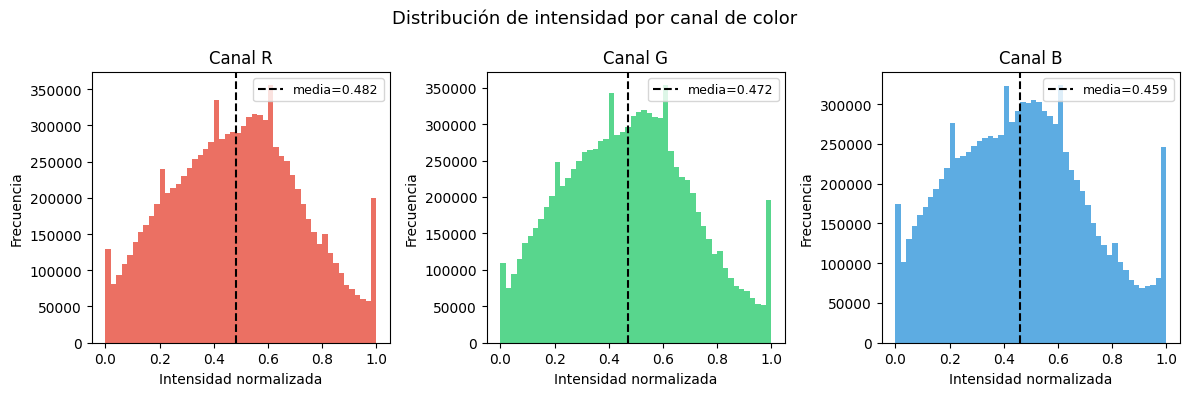

In [10]:
# ── Estadísticas de píxeles (media y desviación estándar por canal) ────────────
print('Calculando estadísticas de píxeles (muestra de 200)...')
sample_idxs_large = random.sample(range(len(split_data)), min(200, len(split_data)))

all_pixels = {0: [], 1: [], 2: []}  # R, G, B
for idx in sample_idxs_large:
    img = split_data[idx][img_key].convert('RGB')
    arr = np.array(img).astype(np.float32) / 255.0  # normalizar a [0,1]
    for c in range(3):
        all_pixels[c].extend(arr[:, :, c].flatten().tolist())

channel_names = ['R', 'G', 'B']
channel_colors = ['#e74c3c', '#2ecc71', '#3498db']

print('\nEstadísticas de canales (valores normalizados 0-1):')
for c in range(3):
    pix = np.array(all_pixels[c])
    print(f'  Canal {channel_names[c]}: mean={pix.mean():.4f}, std={pix.std():.4f}')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for c, (ax, name, color) in enumerate(zip(axes, channel_names, channel_colors)):
    pix = np.array(all_pixels[c])
    ax.hist(pix, bins=50, color=color, alpha=0.8, edgecolor='none')
    ax.axvline(pix.mean(), color='black', linestyle='--', label=f'media={pix.mean():.3f}')
    ax.set_title(f'Canal {name}')
    ax.set_xlabel('Intensidad normalizada')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)

plt.suptitle('Distribución de intensidad por canal de color', fontsize=13)
plt.tight_layout()
plt.savefig('output/pixel_distribution.png', bbox_inches='tight', dpi=120)
plt.show()

### 1.3 Pre-procesamiento y DataLoaders

El dataset ya viene dividido en tres splits: **train (200)**, **validation (165)**, **test (72)**.
Los usamos directamente. Con solo 200 imágenes de entrenamiento aplicamos:
- **Augmentación agresiva** para combatir overfitting
- **Normalización ImageNet** (requerida por InceptionV3 pre-entrenado)

In [11]:
class PotholeDataset(Dataset):
    """
    Wrapper de HuggingFace dataset para PyTorch.
    Convierte imágenes PIL a tensores y aplica transforms.
    """
    def __init__(self, hf_dataset, img_key, label_key, class_names, transform=None):
        self.data        = hf_dataset
        self.img_key     = img_key
        self.label_key   = label_key
        self.class_names = class_names
        self.transform   = transform
        
        # Mapear etiquetas a enteros si son strings
        first_label = hf_dataset[0][label_key]
        self._str_labels = isinstance(first_label, str)
        if self._str_labels:
            self._label_map = {name: i for i, name in enumerate(class_names)}

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item  = self.data[idx]
        image = item[self.img_key].convert('RGB')
        label = item[self.label_key]
        if self._str_labels:
            label = self._label_map[label]
        if self.transform:
            image = self.transform(image)
        return image, int(label)

In [12]:
# ── Parámetros de pre-procesamiento ───────────────────────────────────────────
IMAGE_SIZE = (299, 299)   # InceptionV3 espera 299×299
BATCH_SIZE = 32

# Normalización ImageNet (requerida por pesos pre-entrenados)
MEAN = (0.485, 0.456, 0.406)
STD  = (0.229, 0.224, 0.225)

# ── Transforms ────────────────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.85, 1.15)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

eval_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# ── Usar los splits pre-definidos del dataset ─────────────────────────────────
train_ds_t = PotholeDataset(ds['train'],      img_key, label_key, CLASS_NAMES, transform=train_transform)
val_ds_t   = PotholeDataset(ds['validation'], img_key, label_key, CLASS_NAMES, transform=eval_transform)
test_ds_t  = PotholeDataset(ds['test'],       img_key, label_key, CLASS_NAMES, transform=eval_transform)

n_train = len(train_ds_t)
n_val   = len(val_ds_t)
n_test  = len(test_ds_t)
n_total = n_train + n_val + n_test

print(f'Split final:')
print(f'  Entrenamiento : {n_train} imágenes')
print(f'  Validación    : {n_val}   imágenes')
print(f'  Test          : {n_test}  imágenes')
print(f'  Total         : {n_total} imágenes')

# ── DataLoaders ───────────────────────────────────────────────────────────────
# num_workers=0 es obligatorio en Windows dentro de Jupyter (evita deadlocks)
NUM_WORKERS = 0
pin_memory  = torch.cuda.is_available()

train_loader = DataLoader(train_ds_t, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=pin_memory)
val_loader   = DataLoader(val_ds_t,   batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=pin_memory)
test_loader  = DataLoader(test_ds_t,  batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=pin_memory)

print(f'\nDataLoaders listos — batch_size={BATCH_SIZE}, num_workers={NUM_WORKERS}')
print(f'  Batches train : {len(train_loader)}')
print(f'  Batches val   : {len(val_loader)}')
print(f'  Batches test  : {len(test_loader)}')

Split final:
  Entrenamiento : 200 imágenes
  Validación    : 165   imágenes
  Test          : 72  imágenes
  Total         : 437 imágenes

DataLoaders listos — batch_size=32, num_workers=0
  Batches train : 7
  Batches val   : 6
  Batches test  : 3


---
## 2. Red Neuronal Convolucional con Transfer Learning

### ¿Por qué Transfer Learning?
Con ~500 imágenes entrenar una CNN desde cero generaría overfitting severo.
InceptionV3 pre-entrenado en ImageNet (1.2M imágenes, 1000 clases) ya aprendió
filtros de bajo y alto nivel (bordes, texturas, formas) que son transferibles
a la detección de huecos en carreteras.

**Estrategia de dos fases:**
1. **Feature Extraction**: congelar todo el backbone, entrenar solo el nuevo clasificador
2. **Fine-tuning**: descongelar las últimas capas convolucionales y reentrenar con LR muy bajo

### 2.1 Arquitectura — InceptionV3 para clasificación binaria

In [13]:
def build_pothole_inception(num_classes=2, dropout=0.4):
    """
    InceptionV3 pre-entrenado en ImageNet, adaptado para clasificación binaria.
    
    - Backbone completo congelado
    - Nueva cabeza: Dropout → Linear(num_classes)
    - aux_logits habilitado durante entrenamiento (regularización adicional)
    """
    base = models.inception_v3(
        weights=models.Inception_V3_Weights.IMAGENET1K_V1,
        aux_logits=True
    )

    # Congelar todos los pesos pre-entrenados
    for param in base.parameters():
        param.requires_grad = False

    # Reemplazar cabeza principal
    in_features = base.fc.in_features
    base.fc = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_features, num_classes)
    )

    # Reemplazar cabeza auxiliar
    in_aux = base.AuxLogits.fc.in_features
    base.AuxLogits.fc = nn.Linear(in_aux, num_classes)

    return base


model = build_pothole_inception(num_classes=NUM_CLASSES)

# Resumen de parámetros
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params   = total_params - trainable_params

print('=== Resumen del modelo ===')
print(f'Total de parámetros       : {total_params:,}')
print(f'Parámetros entrenables    : {trainable_params:,}  ({100*trainable_params/total_params:.2f}%)')
print(f'Parámetros congelados     : {frozen_params:,}  ({100*frozen_params/total_params:.2f}%)')

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to C:\Users\juanc/.cache\torch\hub\checkpoints\inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:12<00:00, 8.57MB/s] 


=== Resumen del modelo ===
Total de parámetros       : 24,348,900
Parámetros entrenables    : 5,636  (0.02%)
Parámetros congelados     : 24,343,264  (99.98%)


In [14]:
# Verificar capas entrenables
print('Capas con requires_grad=True:')
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f'  {name:50s} shape={tuple(param.shape)}')

Capas con requires_grad=True:
  AuxLogits.fc.weight                                shape=(2, 768)
  AuxLogits.fc.bias                                  shape=(2,)
  fc.1.weight                                        shape=(2, 2048)
  fc.1.bias                                          shape=(2,)


---
## 3. Entrenamiento y Optimización del Modelo

### 3.1 Fase 1 — Feature Extraction (backbone congelado)

In [15]:
# ── Configuración fase 1 ──────────────────────────────────────────────────────
EPOCHS_PHASE1 = 10
LR_PHASE1     = 1e-3

model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_PHASE1
)

print(f'Dispositivo    : {DEVICE}')
print(f'Épocas fase 1  : {EPOCHS_PHASE1}')
print(f'Learning rate  : {LR_PHASE1}')
print(f'Loss function  : CrossEntropyLoss')
print(f'Optimizer      : Adam')

Dispositivo    : cpu
Épocas fase 1  : 10
Learning rate  : 0.001
Loss function  : CrossEntropyLoss
Optimizer      : Adam


In [16]:
os.makedirs('models', exist_ok=True)
os.makedirs('output', exist_ok=True)

print('=== FASE 1: Feature Extraction ===')
train_losses_p1, val_losses_p1, train_accs_p1, val_accs_p1 = train_model(
    model, 'pothole_inception_phase1',
    train_loader, val_loader,
    criterion, optimizer, DEVICE, EPOCHS_PHASE1
)

=== FASE 1: Feature Extraction ===


Epoch [1/10] Train Loss: 0.9233 | Train Acc: 55.00% | Val Loss: 0.9206 | Val Acc: 40.00%


Epoch [2/10] Train Loss: 0.7679 | Train Acc: 66.50% | Val Loss: 0.5544 | Val Acc: 71.52%


Epoch [3/10] Train Loss: 0.6216 | Train Acc: 71.00% | Val Loss: 0.7197 | Val Acc: 67.27%


Epoch [4/10] Train Loss: 0.5117 | Train Acc: 83.50% | Val Loss: 0.6602 | Val Acc: 74.55%


...

Epoch [6/10] Train Loss: 0.4191 | Train Acc: 89.00% | Val Loss: 0.6881 | Val Acc: 75.15%


Epoch [7/10] Train Loss: 0.4225 | Train Acc: 90.00% | Val Loss: 0.7083 | Val Acc: 75.15%


Epoch [8/10] Train Loss: 0.3429 | Train Acc: 89.50% | Val Loss: 0.7499 | Val Acc: 74.55%


Epoch [9/10] Train Loss: 0.3902 | Train Acc: 91.00% | Val Loss: 0.6886 | Val Acc: 77.58%


Epoch [10/10] Train Loss: 0.3211 | Train Acc: 88.00% | Val Loss: 0.6257 | Val Acc: 78.79%


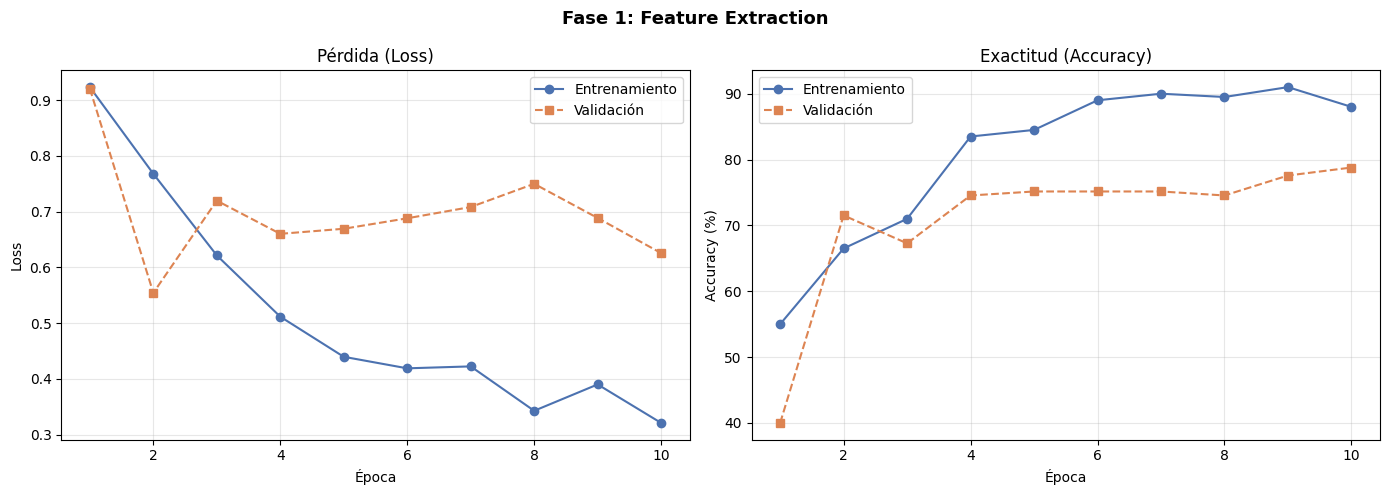

In [17]:
# ── Curvas de aprendizaje fase 1 ─────────────────────────────────────────────
def plot_training_curves(train_losses, val_losses, train_accs, val_accs, title='', save_path=None):
    epochs_range = range(1, len(train_losses) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs_range, train_losses, 'o-', label='Entrenamiento', color='#4C72B0')
    ax1.plot(epochs_range, val_losses,   's--', label='Validación',    color='#DD8452')
    ax1.set_title('Pérdida (Loss)')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(epochs_range, train_accs, 'o-', label='Entrenamiento', color='#4C72B0')
    ax2.plot(epochs_range, val_accs,   's--', label='Validación',    color='#DD8452')
    ax2.set_title('Exactitud (Accuracy)')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=120)
    plt.show()

plot_training_curves(
    train_losses_p1, val_losses_p1,
    train_accs_p1,   val_accs_p1,
    title='Fase 1: Feature Extraction',
    save_path='output/curves_phase1.png'
)

In [18]:
# Evaluación en test al final de fase 1
test_loss_p1, test_acc_p1 = evaluate(model, test_loader, criterion, DEVICE)
print(f'=== Resultados Fase 1 ===')
print(f'Test Loss     : {test_loss_p1:.4f}')
print(f'Test Accuracy : {test_acc_p1:.2f}%')

=== Resultados Fase 1 ===
Test Loss     : 0.5162
Test Accuracy : 70.83%


### 3.2 Fase 2 — Fine-tuning (descongelar últimas capas)

In [19]:
# ── Descongelar Mixed_7b y Mixed_7c (últimas capas convolucionales) ────────────
print('Descongelando Mixed_7b y Mixed_7c ...')

for layer_name in ['Mixed_7b', 'Mixed_7c']:
    layer = getattr(model, layer_name, None)
    if layer is not None:
        for module in layer.modules():
            # Mantener BatchNorm congelado (buena práctica)
            if not isinstance(module, nn.modules.batchnorm._BatchNorm):
                for param in module.parameters(recurse=False):
                    param.requires_grad = True

trainable_after = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parámetros entrenables después del descongelado: {trainable_after:,}')

Descongelando Mixed_7b y Mixed_7c ...
Parámetros entrenables después del descongelado: 11,113,988


In [30]:
# ── Configuración fase 2 (LR mucho más bajo) ──────────────────────────────────
EPOCHS_PHASE2 = 6
LR_PHASE2     = 1e-4  # 10x menor que fase 1

optimizer_ft = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_PHASE2
)

# Scheduler: reducir LR si la validación se estanca
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ft, mode='min', factor=0.5, patience=2
)

print('=== FASE 2: Fine-tuning ===')
train_losses_p2, val_losses_p2, train_accs_p2, val_accs_p2 = train_model(
    model, 'pothole_inception_finetune',
    train_loader, val_loader,
    criterion, optimizer_ft, DEVICE, EPOCHS_PHASE2
)

=== FASE 2: Fine-tuning ===


KeyboardInterrupt: 

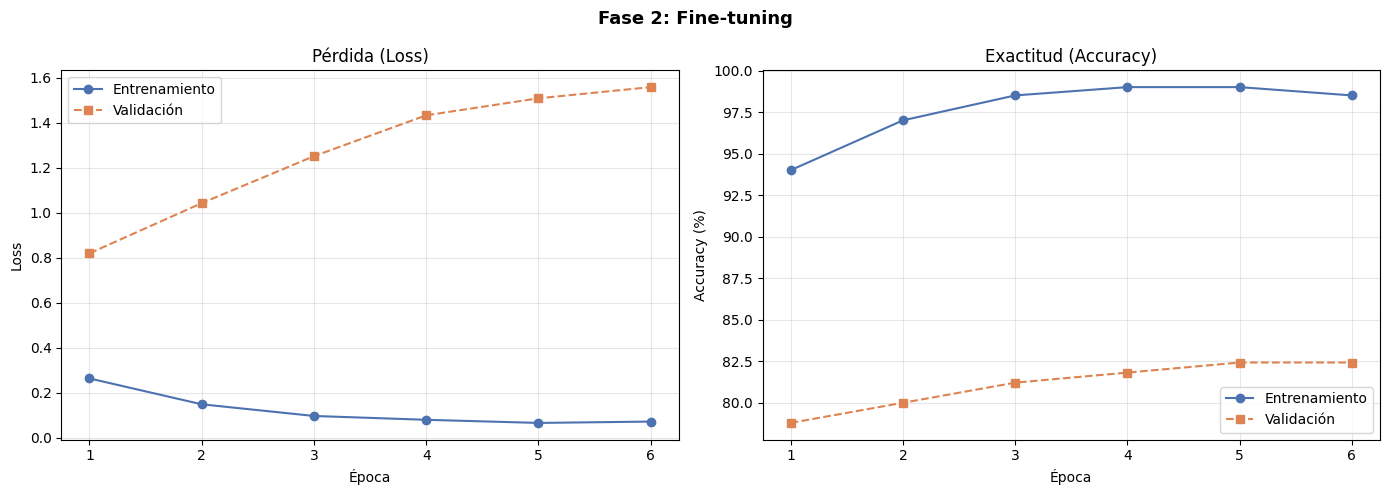

In [31]:
plot_training_curves(
    train_losses_p2, val_losses_p2,
    train_accs_p2,   val_accs_p2,
    title='Fase 2: Fine-tuning',
    save_path='output/curves_phase2.png'
)

In [32]:
test_loss_p2, test_acc_p2 = evaluate(model, test_loader, criterion, DEVICE)
print(f'=== Resultados Fase 2 (Fine-tuning) ===')
print(f'Test Loss     : {test_loss_p2:.4f}')
print(f'Test Accuracy : {test_acc_p2:.2f}%')
print(f'\nMejora vs Fase 1: +{test_acc_p2 - test_acc_p1:.2f}%')

=== Resultados Fase 2 (Fine-tuning) ===
Test Loss     : 1.1874
Test Accuracy : 73.61%

Mejora vs Fase 1: +2.78%


### 3.3 Búsqueda de Hiperparámetros (Random Search)

In [33]:
# ── Grid de hiperparámetros ───────────────────────────────────────────────────
PARAM_GRID = {
    'learning_rate': [1e-3, 5e-4, 1e-4],
    'dropout':       [0.3, 0.4, 0.5],
    'batch_size':    [16, 32],
    'optimizer':     [optim.Adam, optim.SGD],
    'l1_lambda':     [0.0, 0.001],
}

N_ITER           = 6   # Número de experimentos (ajustar según tiempo disponible)
EPOCHS_SEARCH    = 8   # Épocas por experimento

best_acc         = 0.0
best_config      = None
best_model_state = None
experiment_results = []

from src.model_training import train_one_epoch  # para L1 custom

def l1_regularization(mdl):
    return sum(p.abs().sum() for p in mdl.parameters() if p.requires_grad)

print(f'Iniciando Random Search: {N_ITER} experimentos, {EPOCHS_SEARCH} épocas c/u\n')

Iniciando Random Search: 6 experimentos, 8 épocas c/u



In [34]:
from copy import deepcopy
from tqdm import tqdm

tried_configs = []

for trial in range(N_ITER):
    config = {k: random.choice(v) for k, v in PARAM_GRID.items()}
    while config in tried_configs:
        config = {k: random.choice(v) for k, v in PARAM_GRID.items()}
    tried_configs.append(config)

    print(f'--- Trial {trial+1}/{N_ITER} ---')
    print(f'Config: {config}')

    # ── DataLoaders con batch_size del trial ─────────────────────────────────
    t_loader = DataLoader(train_ds_t, batch_size=config['batch_size'], shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=pin_memory)
    v_loader = DataLoader(val_ds_t,   batch_size=config['batch_size'], shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=pin_memory)
    tst_loader = DataLoader(test_ds_t, batch_size=config['batch_size'], shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=pin_memory)

    # ── Modelo fresco ────────────────────────────────────────────────────────
    trial_model = build_pothole_inception(num_classes=NUM_CLASSES, dropout=config['dropout'])
    trial_model = trial_model.to(DEVICE)
    trial_crit  = nn.CrossEntropyLoss()

    opt_kwargs = {'lr': config['learning_rate']}
    if config['optimizer'] == optim.SGD:
        opt_kwargs['momentum'] = 0.9

    trial_opt = config['optimizer'](
        filter(lambda p: p.requires_grad, trial_model.parameters()),
        **opt_kwargs
    )

    # ── Entrenamiento ────────────────────────────────────────────────────────
    trial_train_losses, trial_val_losses = [], []
    trial_train_accs,   trial_val_accs   = [], []

    for epoch in range(EPOCHS_SEARCH):
        trial_model.train()
        running_loss, correct, total = 0.0, 0, 0
        for imgs, lbls in t_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            trial_opt.zero_grad()
            outputs = trial_model(imgs)
            if isinstance(outputs, tuple):
                logits, aux = outputs[0], outputs[1]
                loss = trial_crit(logits, lbls) + 0.4 * trial_crit(aux, lbls)
            else:
                logits = outputs
                loss   = trial_crit(logits, lbls)
            if config['l1_lambda'] > 0:
                loss = loss + config['l1_lambda'] * l1_regularization(trial_model)
            loss.backward()
            trial_opt.step()
            running_loss += loss.item()
            _, pred = logits.max(1)
            total   += lbls.size(0)
            correct += pred.eq(lbls).sum().item()

        tr_loss = running_loss / len(t_loader)
        tr_acc  = 100.0 * correct / total
        vl_loss, vl_acc = evaluate(trial_model, v_loader, trial_crit, DEVICE)

        trial_train_losses.append(tr_loss)
        trial_val_losses.append(vl_loss)
        trial_train_accs.append(tr_acc)
        trial_val_accs.append(vl_acc)

        print(f'  Epoch [{epoch+1}/{EPOCHS_SEARCH}] loss={tr_loss:.4f} acc={tr_acc:.1f}% | val_loss={vl_loss:.4f} val_acc={vl_acc:.1f}%')

    # ── Evaluación ───────────────────────────────────────────────────────────
    tst_loss, tst_acc = evaluate(trial_model, tst_loader, trial_crit, DEVICE)

    experiment_results.append({
        'trial':         trial + 1,
        'config':        config,
        'test_accuracy': tst_acc,
        'test_loss':     tst_loss,
        'train_losses':  trial_train_losses,
        'val_losses':    trial_val_losses,
        'train_accs':    trial_train_accs,
        'val_accs':      trial_val_accs,
    })

    print(f'→ Test Acc: {tst_acc:.2f}%  |  Best so far: {max(best_acc, tst_acc):.2f}%\n')

    if tst_acc > best_acc:
        best_acc         = tst_acc
        best_config      = config
        best_model_state = deepcopy(trial_model.state_dict())

print(f'\n=== MEJOR CONFIGURACIÓN ===')
print(f'Test Accuracy: {best_acc:.2f}%')
print(f'Config: {best_config}')
torch.save(best_model_state, 'models/pothole_best_model.pth')
print('Modelo guardado en models/pothole_best_model.pth')

--- Trial 1/6 ---
Config: {'learning_rate': 0.0001, 'dropout': 0.4, 'batch_size': 16, 'optimizer': <class 'torch.optim.adam.Adam'>, 'l1_lambda': 0.001}
  Epoch [1/8] loss=0.9903 acc=56.5% | val_loss=0.6920 val_acc=50.3%
  Epoch [2/8] loss=0.9984 acc=55.0% | val_loss=0.6986 val_acc=50.3%
  Epoch [3/8] loss=0.9230 acc=58.5% | val_loss=0.6785 val_acc=56.4%
  Epoch [4/8] loss=0.9468 acc=59.0% | val_loss=0.6709 val_acc=63.0%
  Epoch [5/8] loss=0.8703 acc=68.0% | val_loss=0.6650 val_acc=63.6%
  Epoch [6/8] loss=0.8636 acc=63.5% | val_loss=0.6622 val_acc=65.5%
  Epoch [7/8] loss=0.8189 acc=72.5% | val_loss=0.6511 val_acc=66.7%
  Epoch [8/8] loss=0.8215 acc=67.0% | val_loss=0.6486 val_acc=70.3%
→ Test Acc: 61.11%  |  Best so far: 61.11%

--- Trial 2/6 ---
Config: {'learning_rate': 0.0001, 'dropout': 0.5, 'batch_size': 16, 'optimizer': <class 'torch.optim.adam.Adam'>, 'l1_lambda': 0.0}
  Epoch [1/8] loss=0.9996 acc=46.5% | val_loss=0.6879 val_acc=57.6%
  Epoch [2/8] loss=0.9048 acc=58.5% | val_

=== Resultados del Random Search ===


,Trial,LR,Dropout,Batch,Optimizer,L1,Test Acc (%),Test Loss
1,2,0.0001,0.5,16,Adam,0.000,72.22,0.6296
2,3,0.0010,0.3,16,Adam,0.001,72.22,0.5780
3,4,0.0010,0.5,16,Adam,0.000,72.22,0.7022
4,5,0.0005,0.5,32,SGD,0.000,70.83,0.5487
0,1,0.0001,0.4,16,Adam,0.001,61.11,0.6579
5,6,0.0001,0.5,32,Adam,0.001,61.11,0.6271


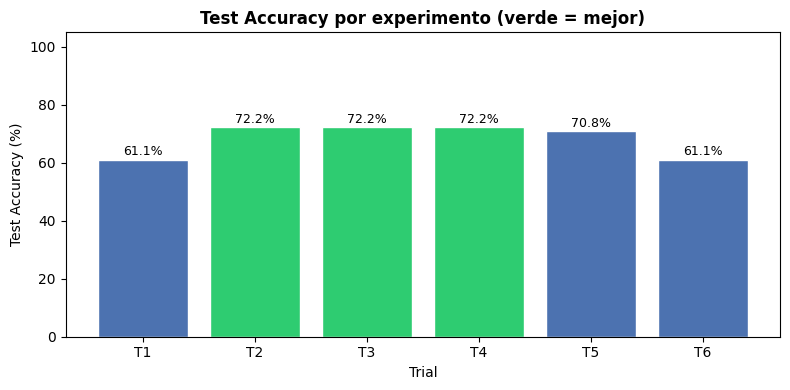

In [35]:
# ── Comparación visual de experimentos ────────────────────────────────────────
import pandas as pd

rows = []
for r in experiment_results:
    rows.append({
        'Trial': r['trial'],
        'LR': r['config']['learning_rate'],
        'Dropout': r['config']['dropout'],
        'Batch': r['config']['batch_size'],
        'Optimizer': r['config']['optimizer'].__name__,
        'L1': r['config']['l1_lambda'],
        'Test Acc (%)': round(r['test_accuracy'], 2),
        'Test Loss': round(r['test_loss'], 4),
    })

df = pd.DataFrame(rows).sort_values('Test Acc (%)', ascending=False)
print('=== Resultados del Random Search ===')
display(df)

# Gráfico de accuracies por trial
fig, ax = plt.subplots(figsize=(8, 4))
colors_bar = ['#2ecc71' if r['test_accuracy'] == best_acc else '#4C72B0'
              for r in experiment_results]
ax.bar([f"T{r['trial']}" for r in experiment_results],
       [r['test_accuracy'] for r in experiment_results],
       color=colors_bar, edgecolor='white')
ax.set_title('Test Accuracy por experimento (verde = mejor)', fontweight='bold')
ax.set_xlabel('Trial')
ax.set_ylabel('Test Accuracy (%)')
ax.set_ylim(0, 105)
for i, r in enumerate(experiment_results):
    ax.text(i, r['test_accuracy'] + 0.5, f"{r['test_accuracy']:.1f}%",
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('output/random_search_results.png', bbox_inches='tight', dpi=120)
plt.show()

### 3.4 Evaluación Final del Mejor Modelo

In [36]:
from sklearn.metrics import (
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

# Cargar el mejor modelo del random search
best_model = build_pothole_inception(num_classes=NUM_CLASSES, dropout=best_config['dropout'])
best_model.load_state_dict(best_model_state)
best_model = best_model.to(DEVICE)
best_model.eval()
if hasattr(best_model, 'aux_logits'):
    best_model.aux_logits = False

# Recolectar predicciones en test set
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(DEVICE)
        out  = best_model(imgs)
        logits = out[0] if isinstance(out, tuple) else out
        preds = logits.argmax(dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(lbls.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print('=== EVALUACIÓN FINAL EN TEST SET ===')
print()
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

=== EVALUACIÓN FINAL EN TEST SET ===

              precision    recall  f1-score   support

  no pothole       0.57      0.92      0.71        26
     pothole       0.93      0.61      0.74        46

    accuracy                           0.72        72
   macro avg       0.75      0.77      0.72        72
weighted avg       0.80      0.72      0.73        72



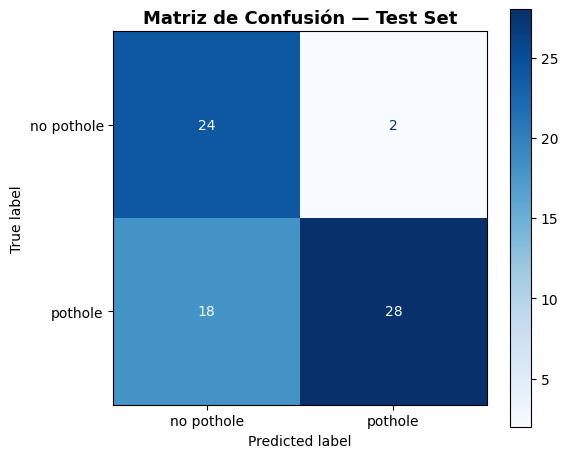


Accuracy final (mejor modelo): 72.22%


In [37]:
# ── Matriz de confusión ───────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Matriz de Confusión — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/confusion_matrix.png', bbox_inches='tight', dpi=120)
plt.show()

# Accuracy final
final_acc = 100.0 * (all_preds == all_labels).sum() / len(all_labels)
print(f'\nAccuracy final (mejor modelo): {final_acc:.2f}%')

---
## 4. Explainability — Grad-CAM
Grad-CAM muestra **qué regiones de la imagen** activaron la decisión del modelo.
Para detección de huecos, esperamos ver calor concentrado sobre los huecos reales.

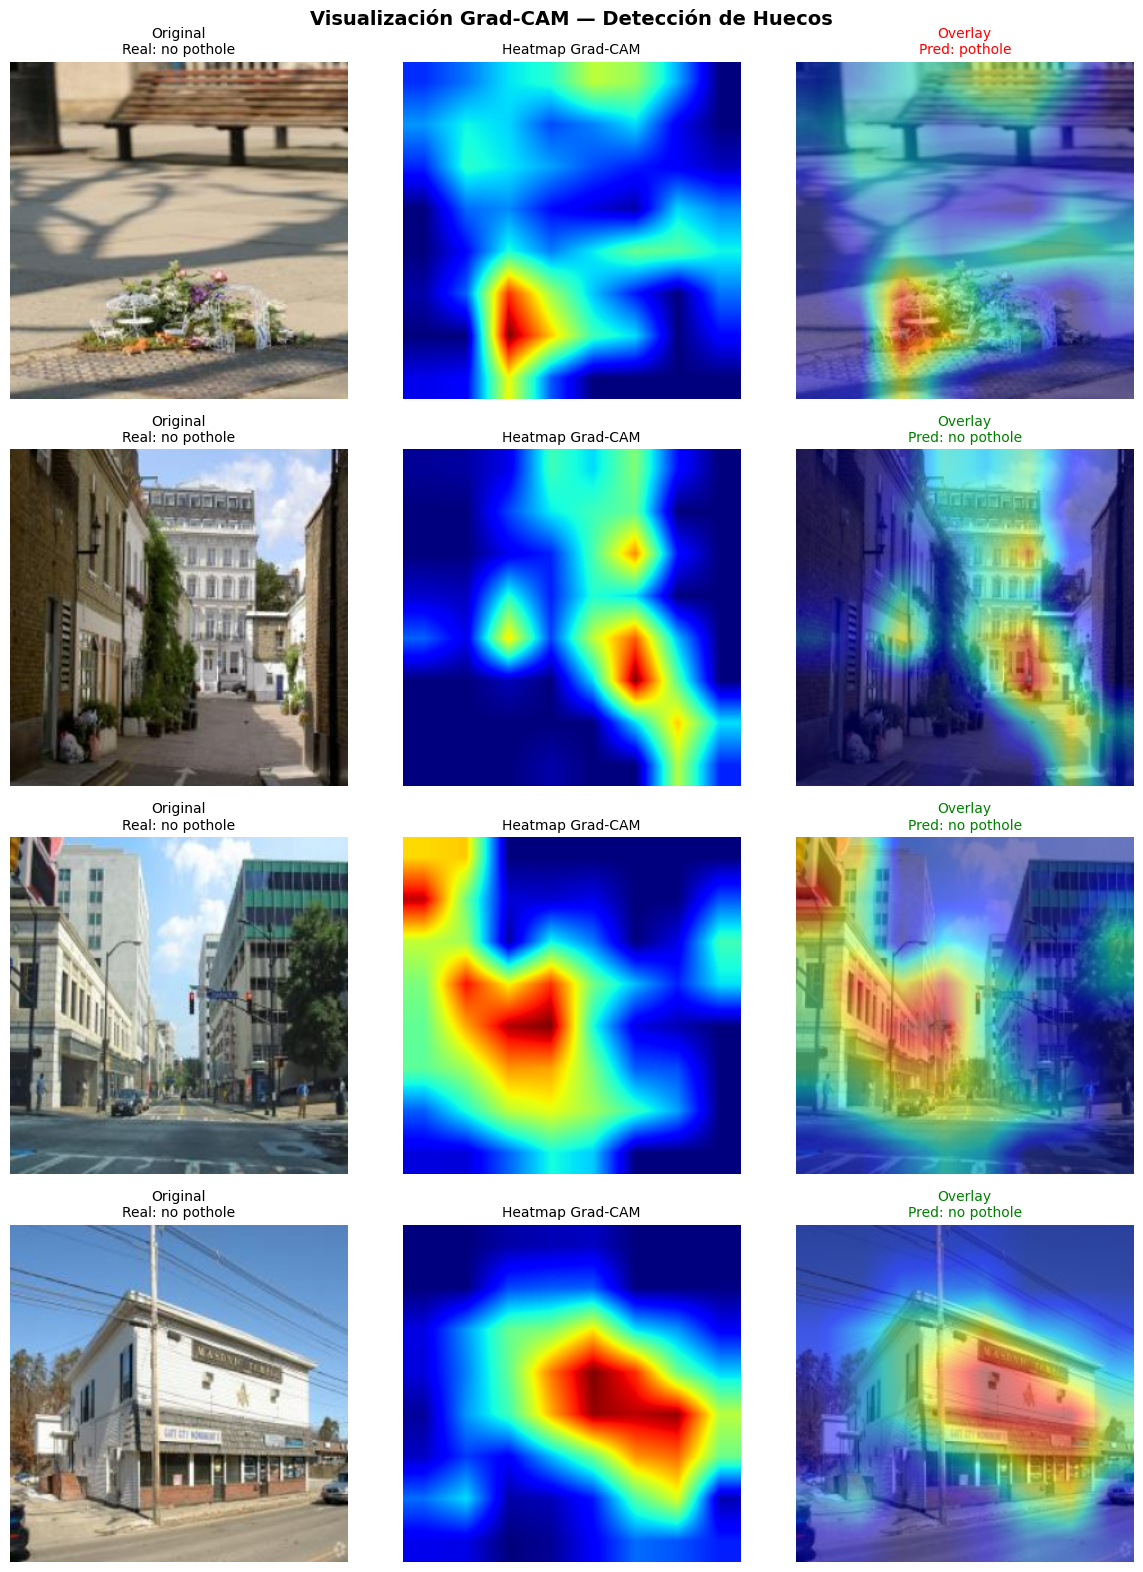

Grad-CAM guardado en output/gradcam_pothole.png


In [39]:
import imageio
import torch.nn.functional as F

def unnorm(img_tensor, mean=MEAN, std=STD):
    img = img_tensor.numpy().transpose(1, 2, 0)
    img = img * np.array(std) + np.array(mean)
    return np.clip(img, 0, 1)

# Usar el mejor modelo con aux_logits desactivado
best_model.eval()
if hasattr(best_model, 'aux_logits'):
    best_model.aux_logits = False

GRADCAM_LAYER = 'Mixed_7c'

N_SAMPLES = 4
test_images, test_labels = next(iter(test_loader))
sample_imgs = test_images[:N_SAMPLES]
sample_lbls = test_labels[:N_SAMPLES]

fig, axes = plt.subplots(N_SAMPLES, 3, figsize=(12, 4 * N_SAMPLES))

for i in range(N_SAMPLES):
    img_t = sample_imgs[i].clone()
    orig_H, orig_W = img_t.shape[1], img_t.shape[2]

    orig_img_viz = unnorm(img_t.cpu())

    inp = img_t.unsqueeze(0).to(DEVICE)
    inp.requires_grad_(True)

    capture, remove = attach_hooks(best_model, GRADCAM_LAYER)
    output, pred = run_forward(best_model, inp)
    run_backward(output, pred)

    cam = compute_gradcam(capture['act'], capture['grad'])
    if cam.shape != (orig_H, orig_W):
        cam = resize_cam(cam, orig_H, orig_W)
    remove()

    orig_uint8 = tensor_to_uint8(torch.tensor(orig_img_viz.transpose(2, 0, 1), dtype=torch.float32))
    cam_np  = np.clip(cam.detach().cpu().numpy(), 0.0, 1.0)
    heatmap = (plt.get_cmap('jet')(cam_np)[:, :, :3] * 255).astype(np.uint8)
    overlay = np.clip(0.5 * orig_uint8 + 0.5 * heatmap, 0, 255).astype(np.uint8)

    true_cls = CLASS_NAMES[sample_lbls[i].item()]
    pred_cls = CLASS_NAMES[pred]
    color    = 'green' if true_cls == pred_cls else 'red'

    axes[i, 0].imshow(orig_img_viz)
    axes[i, 0].set_title(f'Original\nReal: {true_cls}', fontsize=10)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(heatmap)
    axes[i, 1].set_title('Heatmap Grad-CAM', fontsize=10)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(overlay)
    axes[i, 2].set_title(f'Overlay\nPred: {pred_cls}', fontsize=10, color=color)
    axes[i, 2].axis('off')

plt.suptitle('Visualización Grad-CAM — Detección de Huecos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output/gradcam_pothole.png', bbox_inches='tight', dpi=120)
plt.show()
print('Grad-CAM guardado en output/gradcam_pothole.png')

---
## 5. Resumen Final

In [40]:
print('=' * 55)
print('   RESUMEN DEL PROYECTO — POTHOLE DETECTION')
print('=' * 55)
print(f'Dataset           : taroii/pothole-detection')
print(f'Total imágenes    : {n_total}')
print(f'Clases            : {CLASS_NAMES}')
print(f'Modelo base       : InceptionV3 (ImageNet)')
print(f'Estrategia        : Transfer Learning + Fine-tuning')
print()
print(f'Fase 1 (FE)       : {EPOCHS_PHASE1} épocas  →  Test Acc: {test_acc_p1:.2f}%')
print(f'Fase 2 (FT)       : {EPOCHS_PHASE2} épocas  →  Test Acc: {test_acc_p2:.2f}%')
print(f'Mejor Random Srch : Trial {[r for r in experiment_results if r["test_accuracy"]==best_acc][0]["trial"]}  →  Test Acc: {best_acc:.2f}%')
print()
print(f'Mejor config      :')
for k, v in best_config.items():
    val = v.__name__ if callable(v) else v
    print(f'  {k:15s}: {val}')
print()
print('Archivos generados:')
for f in sorted(os.listdir('output')):
    print(f'  output/{f}')
print('  models/pothole_best_model.pth')
print('=' * 55)

   RESUMEN DEL PROYECTO — POTHOLE DETECTION
Dataset           : taroii/pothole-detection
Total imágenes    : 437
Clases            : ['no pothole', 'pothole']
Modelo base       : InceptionV3 (ImageNet)
Estrategia        : Transfer Learning + Fine-tuning

Fase 1 (FE)       : 10 épocas  →  Test Acc: 70.83%
Fase 2 (FT)       : 6 épocas  →  Test Acc: 73.61%
Mejor Random Srch : Trial 2  →  Test Acc: 72.22%

Mejor config      :
  learning_rate  : 0.0001
  dropout        : 0.5
  batch_size     : 16
  optimizer      : Adam
  l1_lambda      : 0.0

Archivos generados:
  output/class_distribution.png
  output/confusion_matrix.png
  output/curves_phase1.png
  output/curves_phase2.png
  output/gradcam_pothole.png
  output/image_dimensions.png
  output/inception_finetune_gradcam.png
  output/pixel_distribution.png
  output/random_search_results.png
  output/sample_images.png
  models/pothole_best_model.pth
